In [1]:
import os
import sys
import random
import math
import time
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np
import mlflow

import tensorflow as tf
tf.keras.mixed_precision.set_global_policy('mixed_float16') # !!!
from tensorflow.keras import Model, Sequential, layers
from tensorflow.keras.layers import Input, concatenate, Conv2D, MaxPooling2D, Conv2DTranspose, Flatten 

2026-04-14 08:49:34.657322: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 08:49:34.675486: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776149374.695832     555 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776149374.701717     555 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776149374.718330     555 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
sys.stderr = open(os.devnull, "w")

I0000 00:00:1776149395.263490     555 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46569 MB memory:  -> device: 0, name: NVIDIA RTX 6000 Ada Generation, pci bus id: 0000:ab:00.0, compute capability: 8.9
I0000 00:00:1776149546.222253     555 cuda_dnn.cc:529] Loaded cuDNN version 90500
2026-04-14 08:54:43.372409: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-14 08:54:43.372445: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.02GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2026-04-14 08:55:06.159844: I tensorflow/core

# Dataloading

In [3]:
notebook_dir = Path().resolve()  # current working directory
parent_dir = notebook_dir.parent
sys.path.insert(0, str(parent_dir))

from data.DataLoader_npz import DataLoader_npz
from data.DataGenerator import DataGenerator

from utils.augmentations import PromptUNetAugmenter
augmenter = PromptUNetAugmenter()

from utils.metrics import dice_score_tf
from utils.visualization import plot_result

In [4]:
datagenerator = DataGenerator(DataLoader_npz(["data/train_data/nako_combined.npz", "data/train_data/total_seg_combined.npz", "data/train_data/msd_combined.npz"], val_size=0.015))


Loading NPZ dataset(s)…
Loaded 61 PIDs from /home/dpxuser/prompt-unet/data/train_data/nako_combined.npz
Loaded 45 PIDs from /home/dpxuser/prompt-unet/data/train_data/total_seg_combined.npz
Loaded 40 PIDs from /home/dpxuser/prompt-unet/data/train_data/msd_combined.npz

Final dataset size: 146 patients.



# Prompt U-Net

In [5]:
epochs = 4000
batch_size = 128
dp_training = 3500 

from optimizer import PromptUNetOptimizer
opt_config = PromptUNetOptimizer(epochs=epochs, batch_size=batch_size, dp_training=dp_training)


In [6]:
from prompt_unet import PromptUNet
model = PromptUNet()

# 1. Define the base optimizer
model.optimizer = opt_config.get_optimizer()
dummy_input = tf.random.uniform([1, datagenerator.height, datagenerator.width, 1])
dummy_prompt = tf.random.uniform([1, datagenerator.height, datagenerator.width, 2])
_ = model.this([dummy_input, dummy_prompt])

--- Encoding prompt ---
p encode shape: (None, 128, 128, 32)
p encode shape: (None, 64, 64, 64)
p encode shape: (None, 32, 32, 128)
p encode shape: (None, 16, 16, 256)
p encode shape: (None, 8, 8, 512)

p encode shape: (None, 4, 4, 1024) 


--- Encoding x (with conditioning on prompt) ---
x,p shape: (None, 128, 128, 32) (None, 128, 128, 32)
x,p shape: (None, 64, 64, 64) (None, 64, 64, 64)
x,p shape: (None, 32, 32, 128) (None, 32, 32, 128)
x,p shape: (None, 16, 16, 256) (None, 16, 16, 256)
x,p shape: (None, 8, 8, 512) (None, 8, 8, 512)

--- Middle part (not in skip connection) ---
x shape: (None, 4, 4, 512) 


--- Decoding / Upsampling (with skip connections) ---
x,concat shape: (None, 8, 8, 512) (None, 8, 8, 512)
x,concat shape: (None, 16, 16, 256) (None, 16, 16, 256)
x,concat shape: (None, 32, 32, 128) (None, 32, 32, 128)
x,concat shape: (None, 64, 64, 64) (None, 64, 64, 64)
x,concat shape: (None, 128, 128, 32) (None, 128, 128, 32)
x shape: (None, 128, 128, 32)


# Training

In [7]:
offset = 12
max_number_labels = 4

dp_training = 3500
dp_testing = 1000

new_ds = 75 # Every x Epochs a new DS is generated
new_val_loop = 300 # Every x Epochs the validation loop is performed

version = 'p_unet_291'

Creating new Data Points ...
It took 15 seconds


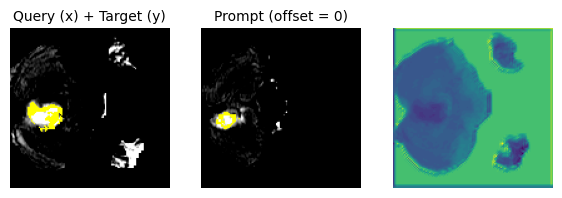

Creating new Data Points ...
It took 96 seconds
............................
Epoch 1, Loss: 0.9082015156745911, 
............................
Epoch 2, Loss: 0.8833352327346802, 
............................
Epoch 3, Loss: 0.8009966015815735, 
............................
Epoch 4, Loss: 0.6637309789657593, 
............................
Epoch 5, Loss: 0.5396379828453064, 
............................
Epoch 6, Loss: 0.4469674527645111, 
............................
Epoch 7, Loss: 0.37552714347839355, 
............................
Epoch 8, Loss: 0.3246561884880066, 
............................
Epoch 9, Loss: 0.28807690739631653, 
............................
Epoch 10, Loss: 0.25952449440956116, 
............................
Epoch 11, Loss: 0.24286602437496185, 
............................
Epoch 12, Loss: 0.23030827939510345, 
............................
Epoch 13, Loss: 0.22282525897026062, 
............................
Epoch 14, Loss: 0.21332493424415588, 
............................
E

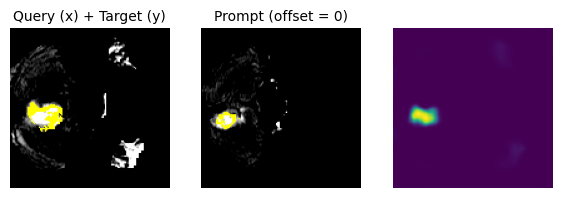

Creating new Data Points ...
It took 103 seconds
............................
Epoch 76, Loss: 0.13920992612838745, 
............................
Epoch 77, Loss: 0.12251853197813034, 
............................
Epoch 78, Loss: 0.11996655911207199, 
............................
Epoch 79, Loss: 0.11604945361614227, 
............................
Epoch 80, Loss: 0.11161944270133972, 
............................
Epoch 81, Loss: 0.11043323576450348, 
............................
Epoch 82, Loss: 0.1097567230463028, 
............................
Epoch 83, Loss: 0.10908662527799606, 
............................
Epoch 84, Loss: 0.10682658851146698, 
............................
Epoch 85, Loss: 0.10519067198038101, 
............................
Epoch 86, Loss: 0.10654174536466599, 
............................
Epoch 87, Loss: 0.10563648492097855, 
............................
Epoch 88, Loss: 0.10362396389245987, 
............................
Epoch 89, Loss: 0.10408497601747513, 
..............

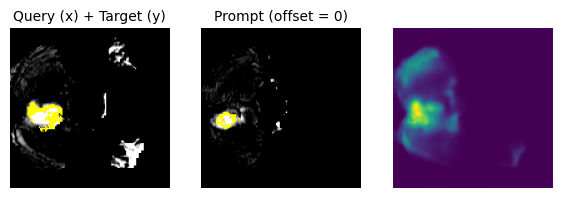

Creating new Data Points ...
It took 109 seconds
............................
Epoch 151, Loss: 0.09148687869310379, 
...................

ResourceExhaustedError: Graph execution error:

Detected at node gradient_tape/functional_1/batch_normalization_35_1/batchnorm/mul_1/Mul_1 defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/software/anaconda3/envs/machauer/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/software/anaconda3/envs/machauer/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance

  File "/software/anaconda3/envs/machauer/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start

  File "/software/anaconda3/envs/machauer/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/software/anaconda3/envs/machauer/lib/python3.11/asyncio/base_events.py", line 608, in run_forever

  File "/software/anaconda3/envs/machauer/lib/python3.11/asyncio/base_events.py", line 1936, in _run_once

  File "/soft

In [8]:
from IPython.display import clear_output

def fit(epochs):
    mlflow.set_experiment(version)

    with mlflow.start_run() as run:
        
        # Log hyperparameters
        mlflow.log_param("batch_size", batch_size)
        mlflow.log_param("max_number_labels", max_number_labels)
        mlflow.log_param("num_epochs", epochs)
        mlflow.log_param("loss_function", "binary_crossentropy")
        
        test_ds, _ = datagenerator.get_val_data_points(max_data_points=dp_testing, 
        offset=offset, max_number_labels=max_number_labels)
     
        test_ds = test_ds.batch(1)
        
        for epoch in range(epochs):  
            # --- Log Lr ---
            current_lr = model.optimizer.learning_rate
            
            if isinstance(current_lr, tf.keras.optimizers.schedules.LearningRateSchedule):
                current_lr = current_lr(epoch)  # evaluate schedule at current epoch
            else:
                current_lr = current_lr.numpy()  # constant value

            mlflow.log_metric("learning_rate", float(current_lr), step=epoch)
            
            model.train_loss.reset_state()

            if epoch%8==0 and epoch != 0:
                
                model_name = f'{version}.keras'
                model.this.save(model_name)
                
            # Validation Loop
            if epoch%new_val_loop==0 and epoch != 0:
                
                total_dice = 0

                for z in test_ds:
                    val_pred = model.this([z[0], z[2]], training=False)
                    total_dice += dice_score_tf(z[1][...,0:1], val_pred)

                total_dice /= dp_testing
                mlflow.log_metric("validation_loss", 1-total_dice, step=epoch)
                print('Validation loss:', str(1-total_dice))

                
            # Pull new random Train Dataset (every x epochs because create_prompt takes some time)
            if epoch%new_ds==0:
                
                # Plot pred for first x examples of val ds
                z_test = next(iter(test_ds))

                pred = model.this([z_test[0], z_test[2]], training=False)
                plot_result(z_test[0][0], z_test[1][0], z_test[2][0], pred[0], 0, "")
                
                # New Ds
                # Clear old dataset first to free memory before allocating new one
                if 'train_ds' in locals():
                    del train_ds
                    import gc
                    gc.collect()
                train_ds, offset_train = datagenerator.get_data_points(max_data_points=dp_training, 
                offset=offset, max_number_labels=max_number_labels)      
                
                # Map pipeline ONCE here instead of every epoch in train_epoch
                train_ds = train_ds.shuffle(256) \
                .map(augmenter, num_parallel_calls=tf.data.AUTOTUNE) \
                .batch(batch_size, drop_remainder=True) \
                .prefetch(tf.data.AUTOTUNE)
                    
            model.train_epoch(train_dataset=train_ds, M=1, batch_size=batch_size)      

            # Display & log metrics at the end of each epoch
            print(f'Epoch {epoch + 1}, '
                  f'Loss: {model.train_loss.result()}, ')
            mlflow.log_metric("train_loss", model.train_loss.result(), step=epoch)

fit(epochs)   